# Crypto Ned Inquiry

In [2]:
import sys
sys.path.append('/Users/fabioballoni/Development/repos/risk/')
from risk_pylibrary import *
from risk_pylibrary.projects.pnl import pnl_support as pnl_sup
import openpyxl


     ------------------------------------------------------------
               Risk @ Trade Republic Bank GmbH
     ------------------------------------------------------------
      Node: fabioballoni	User: fabioballoni
      Python version 3.12.8 (v3.12.8:2dc476bcb91, Dec  3 2024, 14:43:19) [Clang 13.0.0 (clang-1300.0.29.30)]
      pandas: 2.2.3	numpy: 2.2.3
      Kernel started 2025-03-06 11:15
     ------------------------------------------------------------


### Set Global Variables

In [3]:
sdate=date(2022,1,1);
edate=date(2025,2,28);

### Get Asset Info

In [7]:
qry_info='''
SELECT 
    SECS.INSTRUMENT_ID,
    SECS.INSTRUMENT_TYPE,
    SECS.NAME_SHORT,
    SECS.NAME_OFFICIAL,
    SECS.NOTIONAL_CURRENCY AS CURRENCY_MART,
    SECS.INDEX_NAME AS STOCK_INDEX_NAME
FROM 
    TEAMS_PRD.CORE_MART.MRT_CURR__INSTRUMENTS AS SECS
WHERE
    SECS.INSTRUMENT_TYPE='CRYPTO'
'''

df_info=db.run_query(query=qry_info)

### Get Customer AuC

In [4]:
qry_cust_pos='''
SELECT
    *
FROM
    TEAMS_PRD.CORE_MART.MRT_CURR__AUC
WHERE
    JURISDICTION='NL'
AND
    INSTRUMENT_TYPE='CRYPTO'
AND
    CALENDAR_DATE BETWEEN %s AND %s
ORDER BY CALENDAR_DATE DESC;
'''

df_cust_pos=db.run_query(query=qry_cust_pos%(db.sqldate(sdate),db.sqldate(edate)))

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJNb%2BIwEIb%2FSuQ9J3ZIKWABFS1iS9VSykel7c0kA1g4dtbjEOivXxPKqntoD3uz7GfGj%2F1O9%2BaQq2APFqXRPRJHjASgU5NJvemR5WIUtkmATuhMKKOhR46A5KbfRZGrgg9Kt9Uz%2BF0CusA30sjrgx4preZGoESuRQ7IXcrng6dH3ogYL6xxJjWKfCr5vkIggnXe8FKSofR6W%2BcKTmlVVVGVRMZuaIMxRlmHeuqE%2FLjwB%2F%2BmL%2FiYsqsT7wmPTz%2FcbqU%2Bf8F3WqszhPx%2BsZiG0%2Bf5ggSDi%2Bqd0VjmYOdg9zKF5ezxLIDe4OfTdTtptSIowxS0s0KFcYTaVGsldpCavCidbxz5FV1DRpXZSP%2F28bBHip3Mji9TPYFfSXw%2FeXx%2FaG87%2BXS5waNqvM1Gzy%2BrZNVR5nhbvW5HmJLg9RJu4xTuGLGEsT5F6vwWazRDloTsehEzHjd5sx21OuyNBEMfqdTC1ZUXb2%2BagYWiXCmZRmbnRK0oioL%2Btadw2MXtd7M6JDvEh9H%2BcBW3KKKhp5zJeXR4rWH7%2F%2FEhXfq5wccgTnw24%2BHUeK1jMDI2F%2B7r6OIorndkFq5rlEMupBpkmQVEH6FSprqzIJyfd2

In [ ]:
df_cust_pos.sort_values(by='calendar_date')

,calendar_date,auth_account_id,jurisdiction,position_category,instrument_type,legal_instrument_type,instrument_id,net_size,price,volume,incremental_loading_id,_metadata_loaded_ts
24910,2024-09-11,5b7a4292-6edf-45a4-9168-844ab9168e6b,NL,SECURITY,CRYPTO,CRYPTO,XF000CXT0011,82.759533,0.061480,5.088056,2ec0c54422d3d783f9dc70d84e7fe001,2024-11-25 21:32:06.437000+00:00
24898,2024-09-11,900f7006-c08b-466f-ba33-9c0d3cb0fdf9,NL,SECURITY,CRYPTO,CRYPTO,XF000CXT0011,15855.901566,0.061480,974.820828,ae9544d2ed2cf8410bd2ea1b26e3f112,2024-11-25 21:32:06.437000+00:00
24899,2024-09-11,b74c14b7-31db-485c-8d62-3796598756da,NL,SECURITY,CRYPTO,CRYPTO,XF000CXT0011,99.812020,0.061480,6.136443,e3650abf796cd2ee9da86c209a27e2e1,2024-11-25 21:32:06.437000+00:00
24900,2024-09-11,c4d25115-b12b-4af9-94aa-5ee56cff666e,NL,SECURITY,CRYPTO,CRYPTO,XF000CXT0011,814.889663,0.061480,50.099416,980e23a106ed2094af72ec5f0441abd5,2024-11-25 21:32:06.437000+00:00
24901,2024-09-11,5d2d7e56-b63e-475a-b0db-dc20615c388d,NL,SECURITY,CRYPTO,CRYPTO,XF000CXT0011,3933.043861,0.061480,241.803537,0de3293e55e036bdb31ea6e053b674eb,2024-11-25 21:32:06.437000+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
362,2025-02-28,d62ce64c-a6da-4fa1-8cb1-d0280497f306,NL,SECURITY,CRYPTO,CRYPTO,XF000ETC0014,68.849000,18.725400,1289.225065,fbe5f71bf495520e5e889d7687af174e,2025-03-06 05:40:45.559000+00:00
363,2025-02-28,8af262aa-6b5c-4f82-870a-21c268d22848,NL,SECURITY,CRYPTO,CRYPTO,XF0RENDER015,14.520000,3.663360,53.191987,11f7ba80ce3e0ecde00083724cd277dc,2025-03-06 05:40:45.559000+00:00
364,2025-02-28,7a58cb11-bb5f-4a12-a941-902355b41e2a,NL,SECURITY,CRYPTO,CRYPTO,XF000ETC0014,1.034000,18.725400,19.362064,f26fffb8305fb45867397ce10b6a0d6d,2025-03-06 05:40:45.559000+00:00
350,2025-02-28,7c1bd83d-5618-416b-8803-9bbc6245ddd4,NL,SECURITY,CRYPTO,CRYPTO,XF000ETC0014,13.336000,18.725400,249.721934,25ba6f724231eac79033be7198cdc6b4,2025-03-06 05:40:45.559000+00:00


In [27]:
df_cust_pos[['calendar_date','volume']].groupby('calendar_date').sum()[5:]

,volume
calendar_date,
2024-09-16,6456.331292
2024-12-17,487.504130
2024-12-18,3088.898661
2024-12-19,4529.036290
2024-12-20,6798.455700
...,...
2025-02-24,229872.349892
2025-02-25,240156.547293
2025-02-26,233489.949226


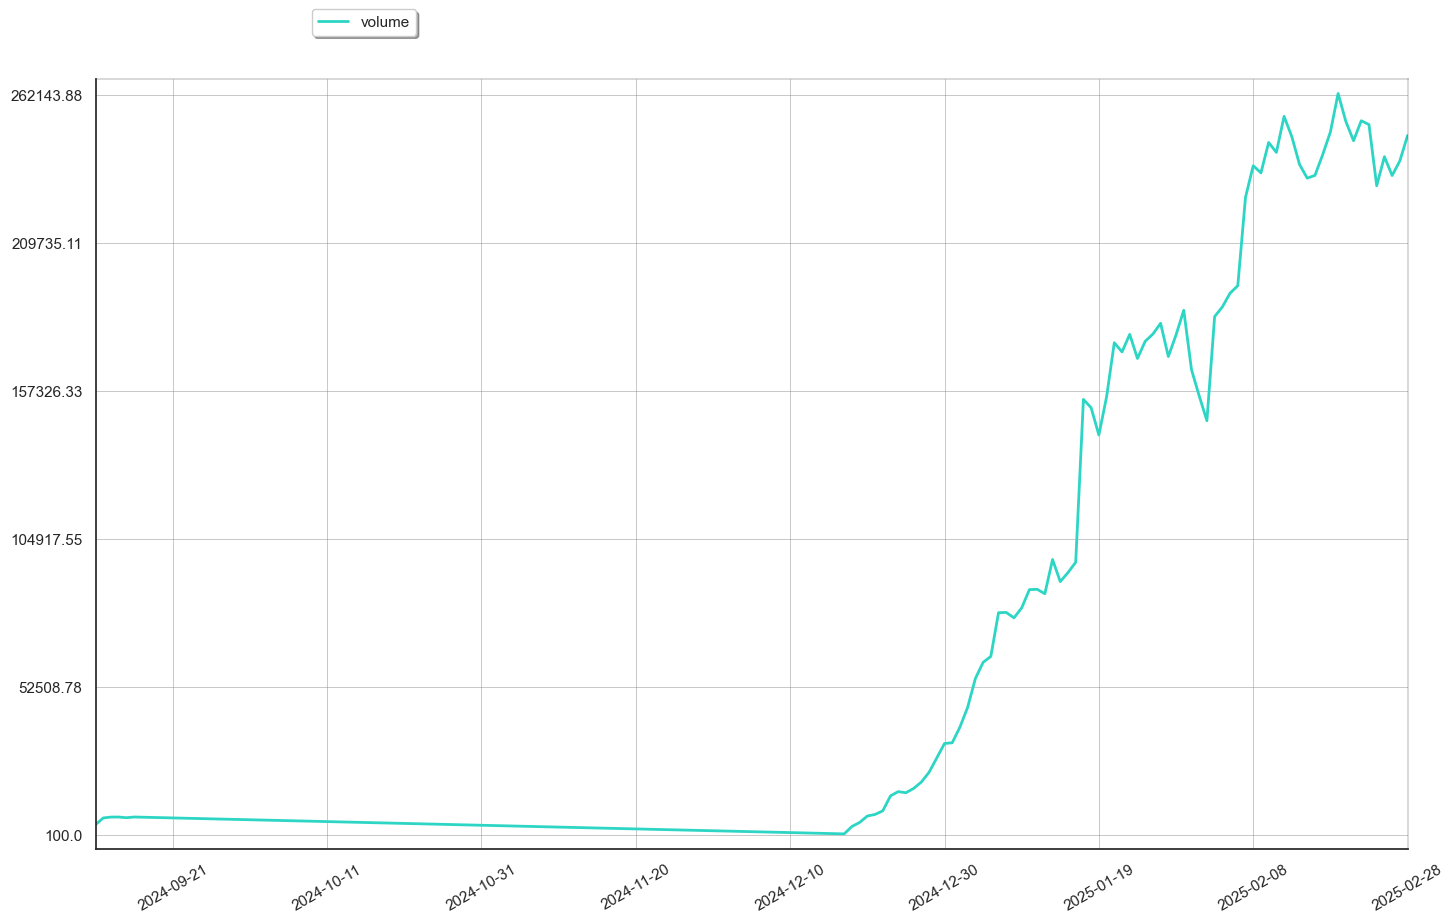

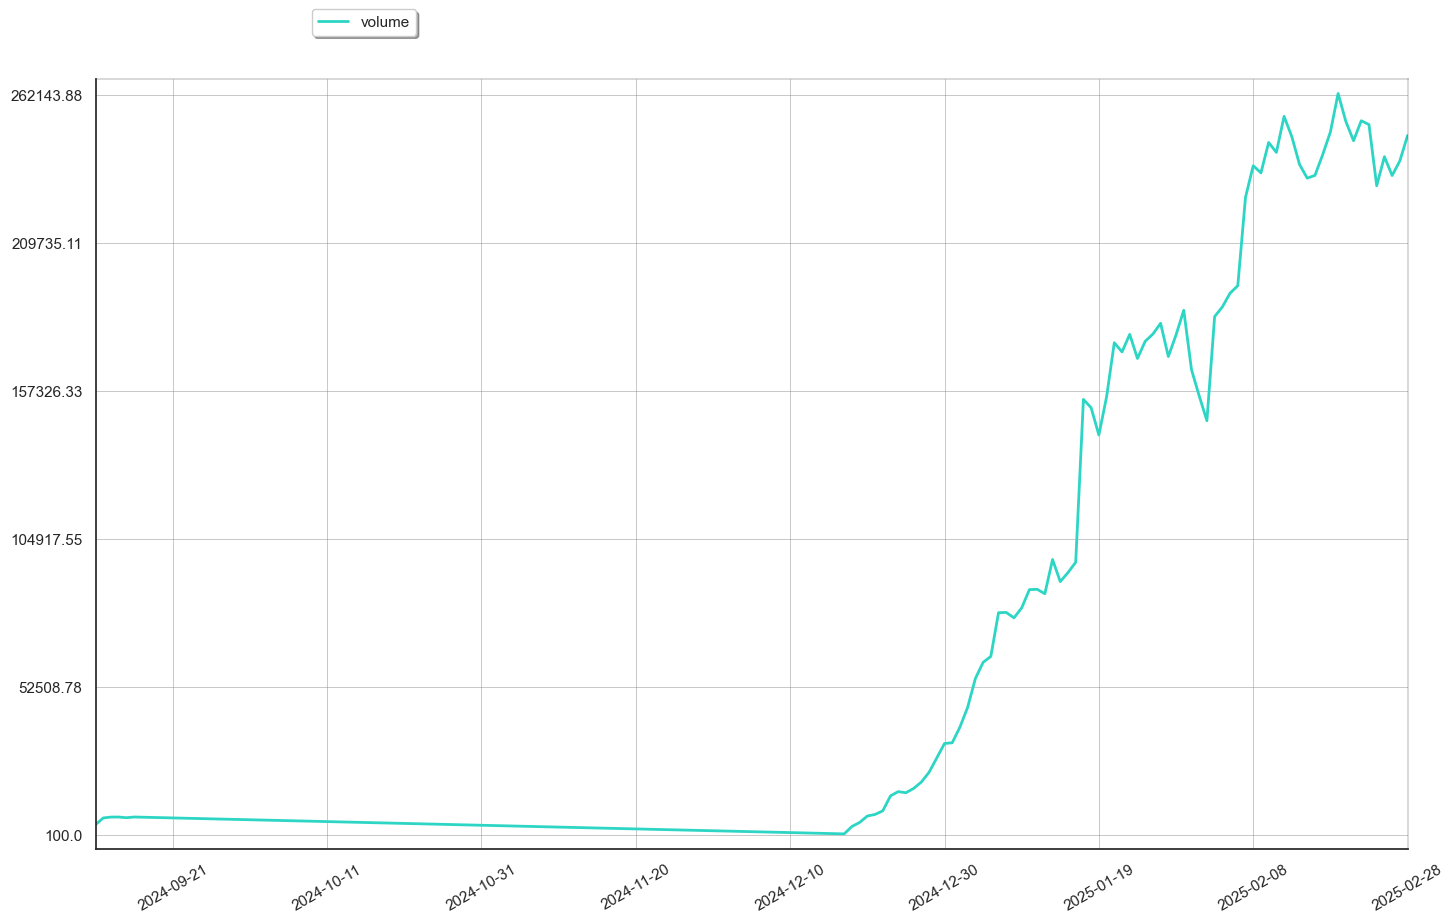

In [22]:
CH.perf_plot(df_cust_pos[['calendar_date','volume']].groupby('calendar_date').sum(),delta=None,annotate=False)